In [ ]:
`f# Cellule 1 — Imports + Installation
!pip install imbalanced-learn -q

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, random
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score, recall_score,
                             precision_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from google.colab import drive

drive.mount('/content/drive')
print("✅ Installation OK !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Installation OK !


In [ ]:
# Cellule 2 — Chargement VitalDB
df_all = pd.read_csv('/content/drive/MyDrive/df_vitaldb_clean.csv')
df_sepsis_A = pd.read_csv('/content/drive/MyDrive/df_sepsis_5000.csv')

def label(row):
    if row['Frequence_Cardiaque_mean'] < 60 or row['Frequence_Cardiaque_mean'] > 100: return 1
    if row['SpO2_mean'] < 95: return 1
    if row['Temperature_mean'] < 34 or row['Temperature_mean'] > 38.5: return 1
    return 0

print(f"✅ VitalDB   : {len(df_all)} lignes")
print(f"✅ Sepsis A  : {len(df_sepsis_A)} lignes")

✅ VitalDB   : 973411 lignes
✅ Sepsis A  : 64107 lignes


In [ ]:
# Cellule 3 — Patient-wise split (VitalDB uniquement)
if 'Target' in df_all.columns:
    df_all = df_all.drop('Target', axis=1)

total_patients = 99
rows_per_patient = len(df_all) // total_patients

df_all['Patient_ID'] = [i // rows_per_patient for i in range(len(df_all))]
df_all['Patient_ID'] = df_all['Patient_ID'].clip(0, total_patients - 1)

train_ids = list(range(0, total_patients))
df_train = df_all[df_all['Patient_ID'].isin(train_ids)].drop('Patient_ID', axis=1)
df_train = df_train.dropna()

print(f"✅ VitalDB TRAIN : {len(df_train)} lignes (99 patients)")

✅ VitalDB TRAIN : 973411 lignes (99 patients)


In [ ]:
# Cellule 4 — Fenêtres glissantes + Labelisation
WINDOW = 10
features = []

for i in range(0, len(df_train) - WINDOW, WINDOW):
    window = df_train.iloc[i:i+WINDOW]
    if window.isnull().values.any():
        continue
    row = {}
    for col in ['Frequence_Cardiaque', 'SpO2', 'Temperature']:
        row[f'{col}_mean'] = window[col].mean()
        row[f'{col}_std']  = window[col].std()
        row[f'{col}_min']  = window[col].min()
        row[f'{col}_max']  = window[col].max()
    features.append(row)

df_windows = pd.DataFrame(features)

def label_train(row):
    if row['Frequence_Cardiaque_mean'] < 60 or row['Frequence_Cardiaque_mean'] > 100: return 1
    if row['SpO2_mean'] < 95: return 1
    if row['Temperature_mean'] < 34 or row['Temperature_mean'] > 38.5: return 1
    return 0

df_windows['Target'] = df_windows.apply(label_train, axis=1)

print(f"✅ Fenêtres TRAIN : {len(df_windows)}")
print(f"Distribution :")
print(df_windows['Target'].value_counts())

✅ Fenêtres TRAIN : 97341
Distribution :
Target
0    74831
1    22510
Name: count, dtype: int64


In [ ]:
# Cellule 5 — SMOTE + Scaler + Split
X = df_windows.drop('Target', axis=1).values
y = df_windows['Target'].values

# SMOTE
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)
print(f"Avant SMOTE : {np.bincount(y)}")
print(f"Après SMOTE : {np.bincount(y_bal)}")

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

# Sauvegarder scaler
with open('/content/drive/MyDrive/scaler_VitalDB_final.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler sauvegardé !")

# Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_bal, test_size=0.2, random_state=42)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")

Avant SMOTE : [74831 22510]
Après SMOTE : [74831 74831]
✅ Scaler sauvegardé !
X_train : (119729, 12)
X_val   : (29933, 12)


In [ ]:
# Cellule 6 — Entraînement MLP
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

model_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(12,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_mlp = model_mlp.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# Sauvegarder modèle + history
model_mlp.save('/content/drive/MyDrive/MLP_VitalDB_final.h5')
with open('/content/drive/MyDrive/history_mlp_final.json', 'w') as f:
    json.dump(history_mlp.history, f)

print("✅ MLP sauvegardé !")

Epoch 1/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9602 - loss: 0.0981 - val_accuracy: 0.9899 - val_loss: 0.0268
Epoch 2/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9845 - loss: 0.0397 - val_accuracy: 0.9935 - val_loss: 0.0186
Epoch 3/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9883 - loss: 0.0311 - val_accuracy: 0.9904 - val_loss: 0.0258
Epoch 4/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9897 - loss: 0.0273 - val_accuracy: 0.9939 - val_loss: 0.0188
Epoch 5/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9909 - loss: 0.0242 - val_accuracy: 0.9945 - val_loss: 0.0143
Epoch 6/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9915 - loss: 0.0225 - val_accuracy: 0.9963 - val_loss: 0.0114
Epoch 7/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9920 - loss: 0.0216 - val_accuracy: 0.9949 - val_loss: 0.0122
Epoch 8/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9924 - loss: 0

✅ MLP sauvegardé !


In [ ]:
# Cellule 7 — Entraînement LSTM
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Reshape pour LSTM
X_train_lstm = X_train.reshape(X_train.shape[0], 3, 4)
X_val_lstm   = X_val.reshape(X_val.shape[0], 3, 4)

model_lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3, 4)),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_lstm, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_lstm, y_val),
    verbose=1
)

# Sauvegarder modèle + history
model_lstm.save('/content/drive/MyDrive/LSTM_VitalDB_final.h5')
with open('/content/drive/MyDrive/history_lstm_final.json', 'w') as f:
    json.dump(history_lstm.history, f)

print("✅ LSTM sauvegardé !")

Epoch 1/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9807 - loss: 0.0534 - val_accuracy: 0.9929 - val_loss: 0.0181
Epoch 2/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9932 - loss: 0.0184 - val_accuracy: 0.9944 - val_loss: 0.0131
Epoch 3/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9942 - loss: 0.0156 - val_accuracy: 0.9957 - val_loss: 0.0116
Epoch 4/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9948 - loss: 0.0142 - val_accuracy: 0.9947 - val_loss: 0.0115
Epoch 5/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9952 - loss: 0.0131 - val_accuracy: 0.9965 - val_loss: 0.0096
Epoch 6/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.9956 - loss: 0.0119 - val_accuracy: 0.9967 - val_loss: 0.0110
Epoch 7/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.9958 - loss: 0.0110 - val_accuracy: 0.9965 - val_loss: 0.0093
Epoch 8/30
3742/3742 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9962 - loss: 0

✅ LSTM sauvegardé !


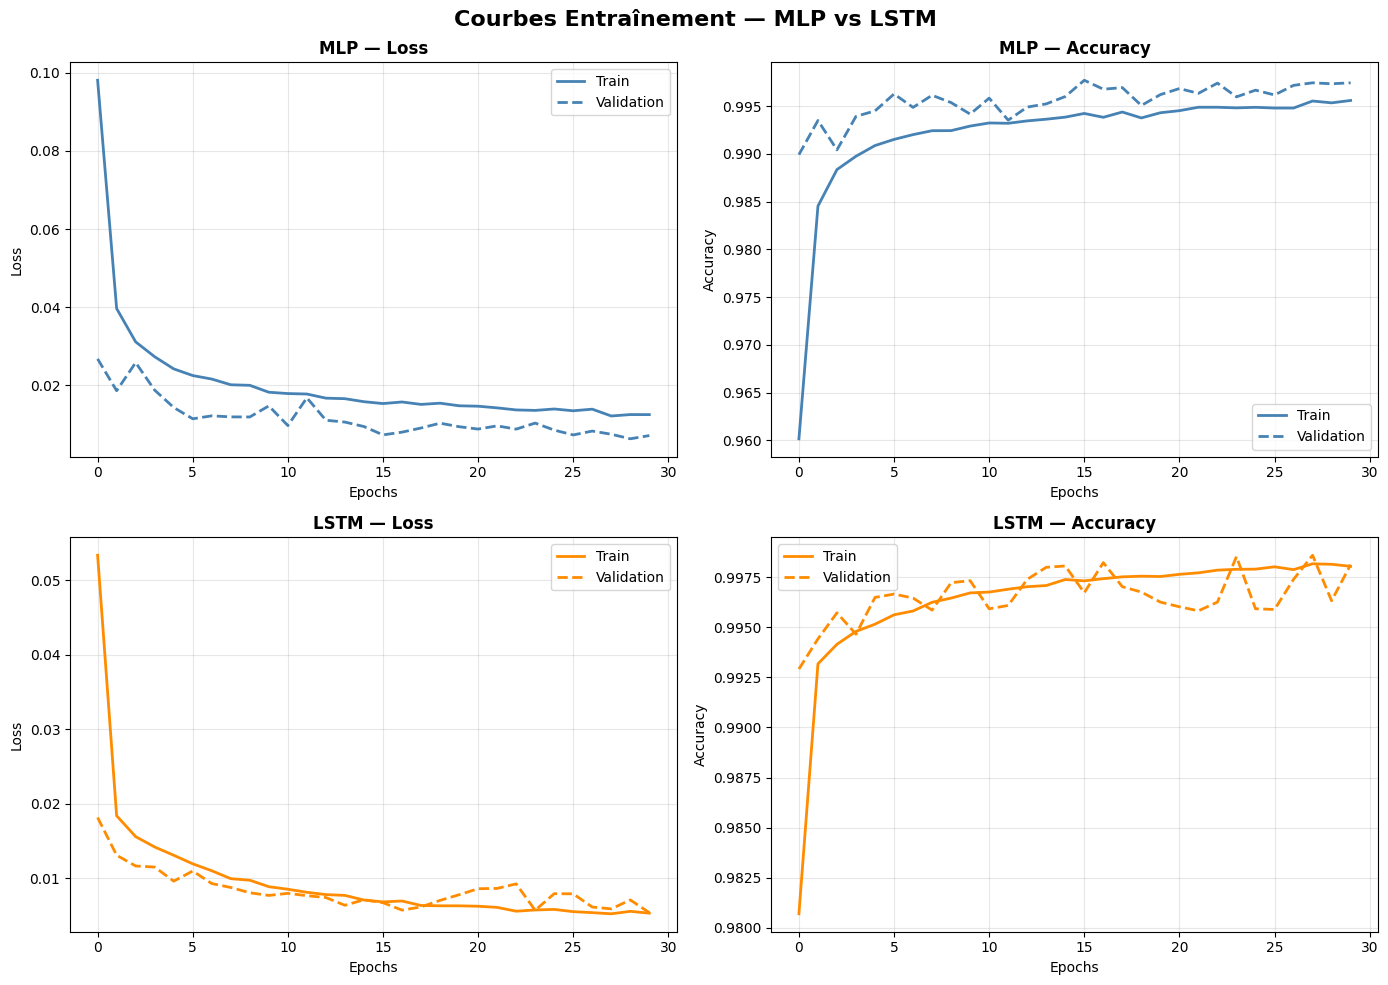

✅ Courbes sauvegardées sur Drive !


In [ ]:
# Cellule 8 — Courbes Loss / Accuracy MLP vs LSTM
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Courbes Entraînement — MLP vs LSTM', fontsize=16, fontweight='bold')

# MLP Loss
axes[0,0].plot(history_mlp.history['loss'],     color='steelblue',  lw=2, label='Train')
axes[0,0].plot(history_mlp.history['val_loss'],  color='steelblue',  lw=2, linestyle='--', label='Validation')
axes[0,0].set_title('MLP — Loss', fontweight='bold')
axes[0,0].set_xlabel('Epochs')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# MLP Accuracy
axes[0,1].plot(history_mlp.history['accuracy'],     color='steelblue',  lw=2, label='Train')
axes[0,1].plot(history_mlp.history['val_accuracy'],  color='steelblue',  lw=2, linestyle='--', label='Validation')
axes[0,1].set_title('MLP — Accuracy', fontweight='bold')
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# LSTM Loss
axes[1,0].plot(history_lstm.history['loss'],     color='darkorange', lw=2, label='Train')
axes[1,0].plot(history_lstm.history['val_loss'],  color='darkorange', lw=2, linestyle='--', label='Validation')
axes[1,0].set_title('LSTM — Loss', fontweight='bold')
axes[1,0].set_xlabel('Epochs')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# LSTM Accuracy
axes[1,1].plot(history_lstm.history['accuracy'],     color='darkorange', lw=2, label='Train')
axes[1,1].plot(history_lstm.history['val_accuracy'],  color='darkorange', lw=2, linestyle='--', label='Validation')
axes[1,1].set_title('LSTM — Accuracy', fontweight='bold')
axes[1,1].set_xlabel('Epochs')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/courbes_entrainement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes sauvegardées sur Drive !")

In [ ]:
# Cellule 9 — Fenêtres Sepsis SetA + Prédictions
WINDOW = 10
features_A = []
for i in range(0, len(df_sepsis_A) - WINDOW, WINDOW):
    window = df_sepsis_A.iloc[i:i+WINDOW]
    if window.isnull().values.any():
        continue
    row = {}
    for col in ['Frequence_Cardiaque', 'SpO2', 'Temperature']:
        row[f'{col}_mean'] = window[col].mean()
        row[f'{col}_std']  = window[col].std()
        row[f'{col}_min']  = window[col].min()
        row[f'{col}_max']  = window[col].max()
    features_A.append(row)

df_A_w = pd.DataFrame(features_A)
df_A_w['Target'] = df_A_w.apply(label, axis=1)

# Sauvegarder fenêtres
df_A_w.to_csv('/content/drive/MyDrive/df_sepsis_A_windows.csv', index=False)

X_A = scaler.transform(df_A_w.drop('Target', axis=1).values)
y_A = df_A_w['Target'].values
X_A_lstm = X_A.reshape(X_A.shape[0], 3, 4)

y_pred_mlp_A  = (model_mlp.predict(X_A, verbose=0) > 0.5).astype(int).flatten()
y_pred_lstm_A = (model_lstm.predict(X_A_lstm, verbose=0) > 0.5).astype(int).flatten()
y_prob_mlp_A  = model_mlp.predict(X_A, verbose=0).flatten()
y_prob_lstm_A = model_lstm.predict(X_A_lstm, verbose=0).flatten()

print(f"✅ SetA : {len(y_A)} cas | Normal : {(y_A==0).sum()} | Anomalie : {(y_A==1).sum()}")

✅ SetA : 6410 cas | Normal : 5126 | Anomalie : 1284


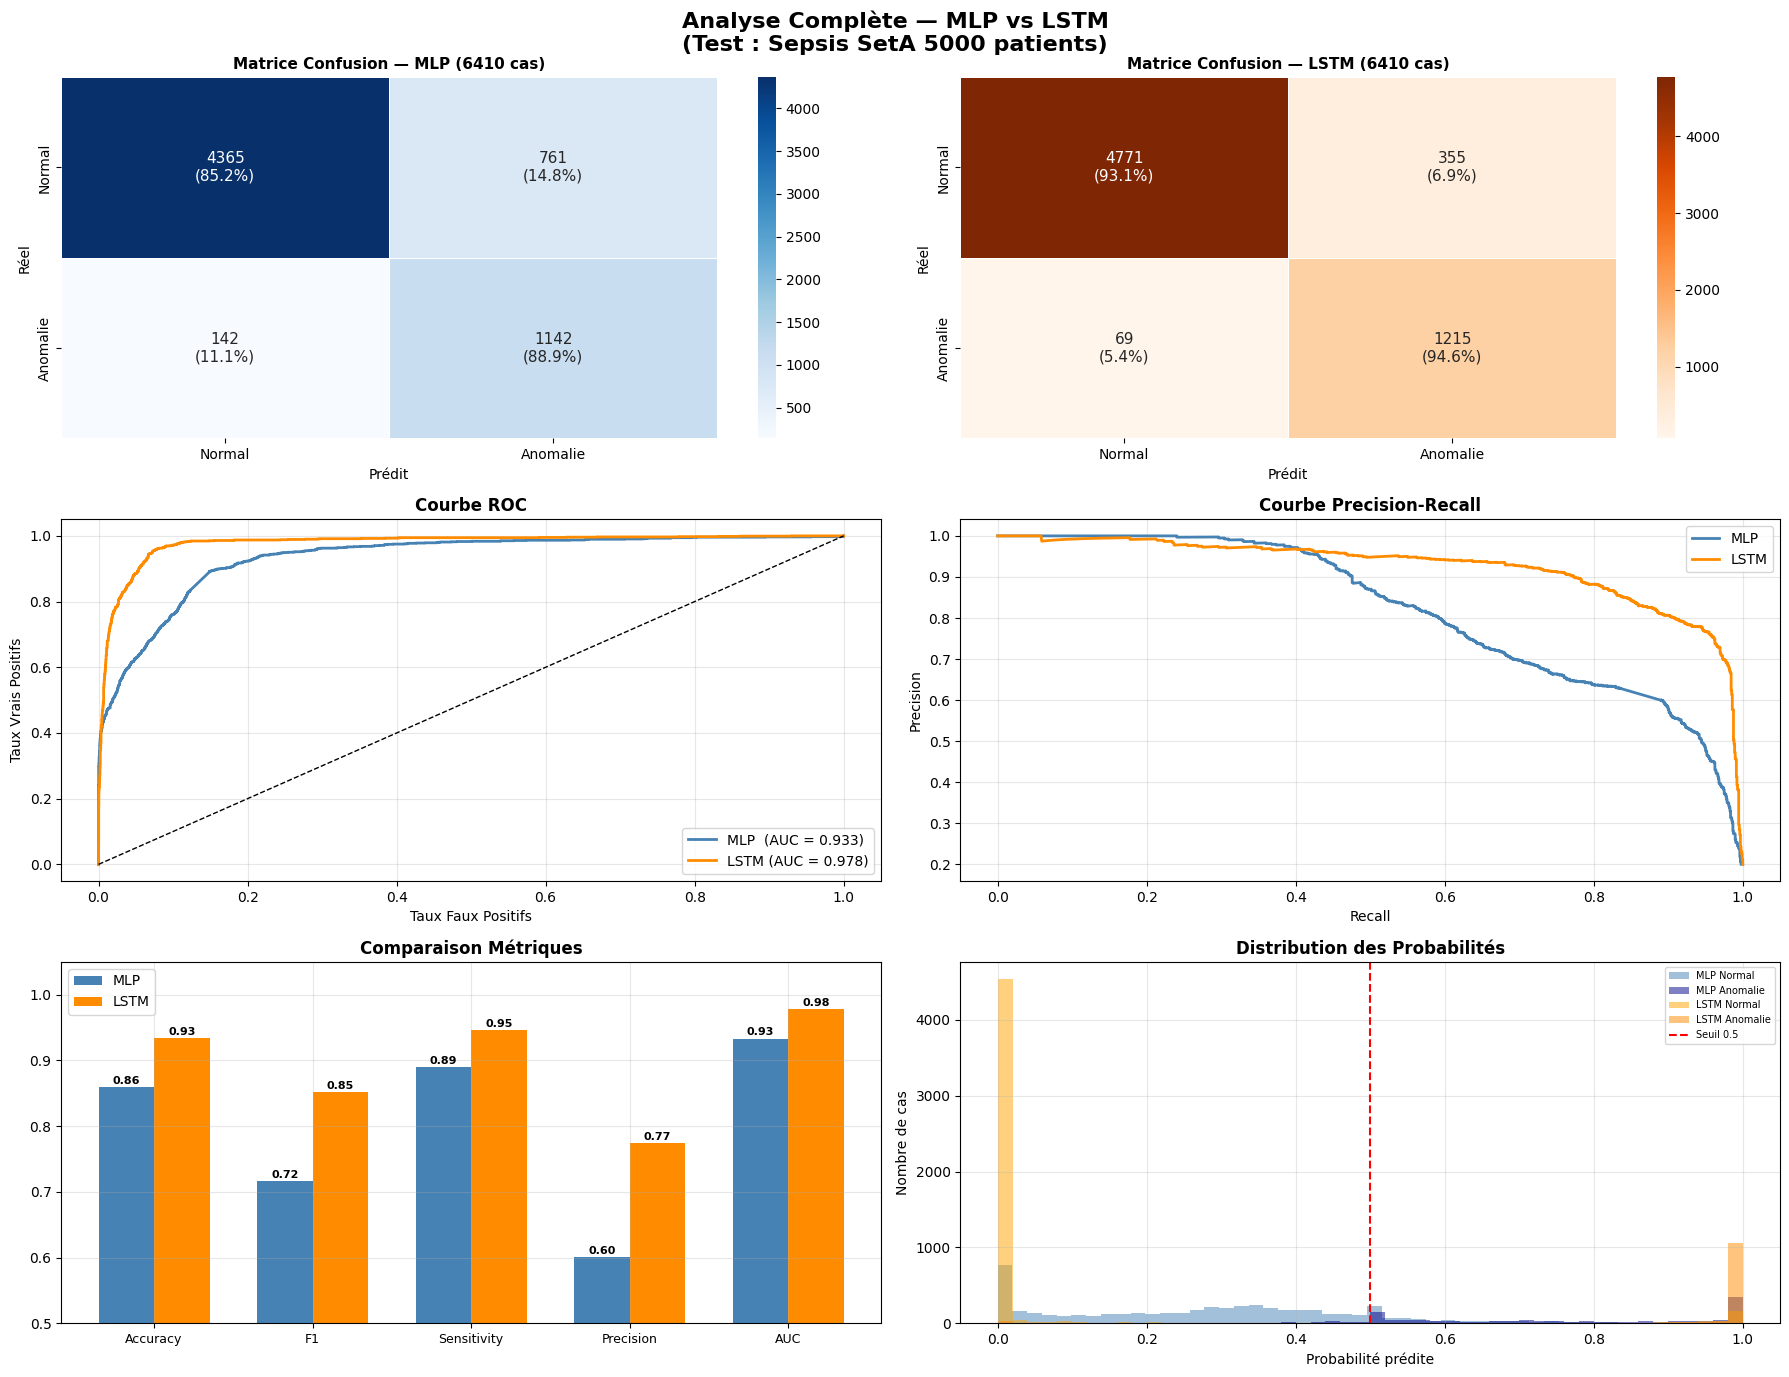

✅ SetA : 6410 cas | Normal : 5126 | Anomalie : 1284

MLP :
              precision    recall  f1-score   support

      Normal       0.97      0.85      0.91      5126
    Anomalie       0.60      0.89      0.72      1284

    accuracy                           0.86      6410
   macro avg       0.78      0.87      0.81      6410
weighted avg       0.89      0.86      0.87      6410

LSTM :
              precision    recall  f1-score   support

      Normal       0.99      0.93      0.96      5126
    Anomalie       0.77      0.95      0.85      1284

    accuracy                           0.93      6410
   macro avg       0.88      0.94      0.90      6410
weighted avg       0.94      0.93      0.94      6410



In [ ]:
# Cellule 10 — Analyse complète SetA
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Analyse Complète — MLP vs LSTM\n(Test : Sepsis SetA 5000 patients)',
             fontsize=16, fontweight='bold')

def plot_cm(ax, cm, title, cmap):
    annot = np.array([[f"{cm[i,j]}\n({cm[i,j]/cm[i].sum()*100:.1f}%)"
                       for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, ax=ax,
                xticklabels=['Normal','Anomalie'],
                yticklabels=['Normal','Anomalie'],
                linewidths=0.5, annot_kws={"size": 11})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

# 1. Matrice MLP
ax1 = fig.add_subplot(3, 2, 1)
cm_mlp_A = confusion_matrix(y_A, y_pred_mlp_A)
plot_cm(ax1, cm_mlp_A, f'Matrice Confusion — MLP ({len(y_A)} cas)', 'Blues')

# 2. Matrice LSTM
ax2 = fig.add_subplot(3, 2, 2)
cm_lstm_A = confusion_matrix(y_A, y_pred_lstm_A)
plot_cm(ax2, cm_lstm_A, f'Matrice Confusion — LSTM ({len(y_A)} cas)', 'Oranges')

# 3. Courbe ROC
ax3 = fig.add_subplot(3, 2, 3)
fpr_mlp_A, tpr_mlp_A, _ = roc_curve(y_A, y_prob_mlp_A)
fpr_lstm_A, tpr_lstm_A, _ = roc_curve(y_A, y_prob_lstm_A)
auc_mlp_A  = auc(fpr_mlp_A, tpr_mlp_A)
auc_lstm_A = auc(fpr_lstm_A, tpr_lstm_A)
ax3.plot(fpr_mlp_A,  tpr_mlp_A,  color='steelblue',  lw=2, label=f'MLP  (AUC = {auc_mlp_A:.3f})')
ax3.plot(fpr_lstm_A, tpr_lstm_A, color='darkorange', lw=2, label=f'LSTM (AUC = {auc_lstm_A:.3f})')
ax3.plot([0,1], [0,1], 'k--', lw=1)
ax3.set_xlabel('Taux Faux Positifs')
ax3.set_ylabel('Taux Vrais Positifs')
ax3.set_title('Courbe ROC', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Courbe Precision-Recall
ax4 = fig.add_subplot(3, 2, 4)
prec_mlp_A,  rec_mlp_A,  _ = precision_recall_curve(y_A, y_prob_mlp_A)
prec_lstm_A, rec_lstm_A, _ = precision_recall_curve(y_A, y_prob_lstm_A)
ax4.plot(rec_mlp_A,  prec_mlp_A,  color='steelblue',  lw=2, label='MLP')
ax4.plot(rec_lstm_A, prec_lstm_A, color='darkorange', lw=2, label='LSTM')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Courbe Precision-Recall', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Comparaison Métriques
ax5 = fig.add_subplot(3, 2, 5)
metrics = ['Accuracy', 'F1', 'Sensitivity', 'Precision', 'AUC']
mlp_scores  = [accuracy_score(y_A, y_pred_mlp_A),
               f1_score(y_A, y_pred_mlp_A),
               recall_score(y_A, y_pred_mlp_A),
               precision_score(y_A, y_pred_mlp_A),
               auc_mlp_A]
lstm_scores = [accuracy_score(y_A, y_pred_lstm_A),
               f1_score(y_A, y_pred_lstm_A),
               recall_score(y_A, y_pred_lstm_A),
               precision_score(y_A, y_pred_lstm_A),
               auc_lstm_A]
x = np.arange(len(metrics))
width = 0.35
ax5.bar(x - width/2, mlp_scores,  width, label='MLP',  color='steelblue')
ax5.bar(x + width/2, lstm_scores, width, label='LSTM', color='darkorange')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics, fontsize=9)
ax5.set_ylim(0.5, 1.05)
ax5.set_title('Comparaison Métriques', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
for i, (m, l) in enumerate(zip(mlp_scores, lstm_scores)):
    ax5.text(i - width/2, m + 0.005, f'{m:.2f}', ha='center', fontsize=8, fontweight='bold')
    ax5.text(i + width/2, l + 0.005, f'{l:.2f}', ha='center', fontsize=8, fontweight='bold')

# 6. Distribution probabilités
ax6 = fig.add_subplot(3, 2, 6)
ax6.hist(y_prob_mlp_A[y_A==0],  bins=50, alpha=0.5, color='steelblue',  label='MLP Normal')
ax6.hist(y_prob_mlp_A[y_A==1],  bins=50, alpha=0.5, color='darkblue',   label='MLP Anomalie')
ax6.hist(y_prob_lstm_A[y_A==0], bins=50, alpha=0.5, color='orange',     label='LSTM Normal')
ax6.hist(y_prob_lstm_A[y_A==1], bins=50, alpha=0.5, color='darkorange', label='LSTM Anomalie')
ax6.axvline(x=0.5, color='red', linestyle='--', label='Seuil 0.5')
ax6.set_xlabel('Probabilité prédite')
ax6.set_ylabel('Nombre de cas')
ax6.set_title('Distribution des Probabilités', fontweight='bold')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/analyse_SetA.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ SetA : {len(y_A)} cas | Normal : {(y_A==0).sum()} | Anomalie : {(y_A==1).sum()}")
print("\nMLP :")
print(classification_report(y_A, y_pred_mlp_A, target_names=['Normal','Anomalie']))
print("LSTM :")
print(classification_report(y_A, y_pred_lstm_A, target_names=['Normal','Anomalie']))

In [ ]:
# Cellule 11 — Chargement Sepsis SetB 5000 patients
import requests

all_data_B = []
print("Chargement Sepsis SetB — 5000 patients...")

for i in range(100001, 105001):
    try:
        url = f"https://physionet.org/files/challenge-2019/1.0.0/training/training_setB/p{i:06d}.psv"
        df = pd.read_csv(url, sep='|')
        df = df[['HR', 'O2Sat', 'Temp']].copy()
        df.columns = ['Frequence_Cardiaque', 'SpO2', 'Temperature']
        df = df.dropna()
        df = df[
            (df['Frequence_Cardiaque'] >= 30) & (df['Frequence_Cardiaque'] <= 200) &
            (df['SpO2'] >= 70) & (df['SpO2'] <= 100) &
            (df['Temperature'] >= 33) & (df['Temperature'] <= 42)
        ]
        if len(df) > 0:
            all_data_B.append(df)
        if i % 500 == 0:
            print(f"✅ {i-100000}/5000 patients...")
    except:
        continue

df_sepsis_B = pd.concat(all_data_B, ignore_index=True)
df_sepsis_B.to_csv('/content/drive/MyDrive/df_sepsis_B_5000.csv', index=False)
print(f"✅ Sepsis SetB sauvegardé : {len(df_sepsis_B)} lignes")

Chargement Sepsis SetB — 5000 patients...
✅ 500/5000 patients...
✅ 1000/5000 patients...
✅ 1500/5000 patients...
✅ 2000/5000 patients...
✅ 2500/5000 patients...
✅ 3000/5000 patients...
✅ 3500/5000 patients...
✅ 4000/5000 patients...
✅ 4500/5000 patients...
✅ 5000/5000 patients...
✅ Sepsis SetB sauvegardé : 62248 lignes


In [ ]:
# Cellule 12 — Fenêtres Sepsis SetB + Prédictions
WINDOW = 10
features_B = []
for i in range(0, len(df_sepsis_B) - WINDOW, WINDOW):
    window = df_sepsis_B.iloc[i:i+WINDOW]
    if window.isnull().values.any():
        continue
    row = {}
    for col in ['Frequence_Cardiaque', 'SpO2', 'Temperature']:
        row[f'{col}_mean'] = window[col].mean()
        row[f'{col}_std']  = window[col].std()
        row[f'{col}_min']  = window[col].min()
        row[f'{col}_max']  = window[col].max()
    features_B.append(row)

df_B_w = pd.DataFrame(features_B)
df_B_w['Target'] = df_B_w.apply(label, axis=1)

# Sauvegarder fenêtres
df_B_w.to_csv('/content/drive/MyDrive/df_sepsis_B_windows.csv', index=False)

X_B = scaler.transform(df_B_w.drop('Target', axis=1).values)
y_B = df_B_w['Target'].values
X_B_lstm = X_B.reshape(X_B.shape[0], 3, 4)

y_pred_mlp_B  = (model_mlp.predict(X_B, verbose=0) > 0.5).astype(int).flatten()
y_pred_lstm_B = (model_lstm.predict(X_B_lstm, verbose=0) > 0.5).astype(int).flatten()
y_prob_mlp_B  = model_mlp.predict(X_B, verbose=0).flatten()
y_prob_lstm_B = model_lstm.predict(X_B_lstm, verbose=0).flatten()

print(f"✅ SetB : {len(y_B)} cas | Normal : {(y_B==0).sum()} | Anomalie : {(y_B==1).sum()}")

✅ SetB : 6224 cas | Normal : 4778 | Anomalie : 1446


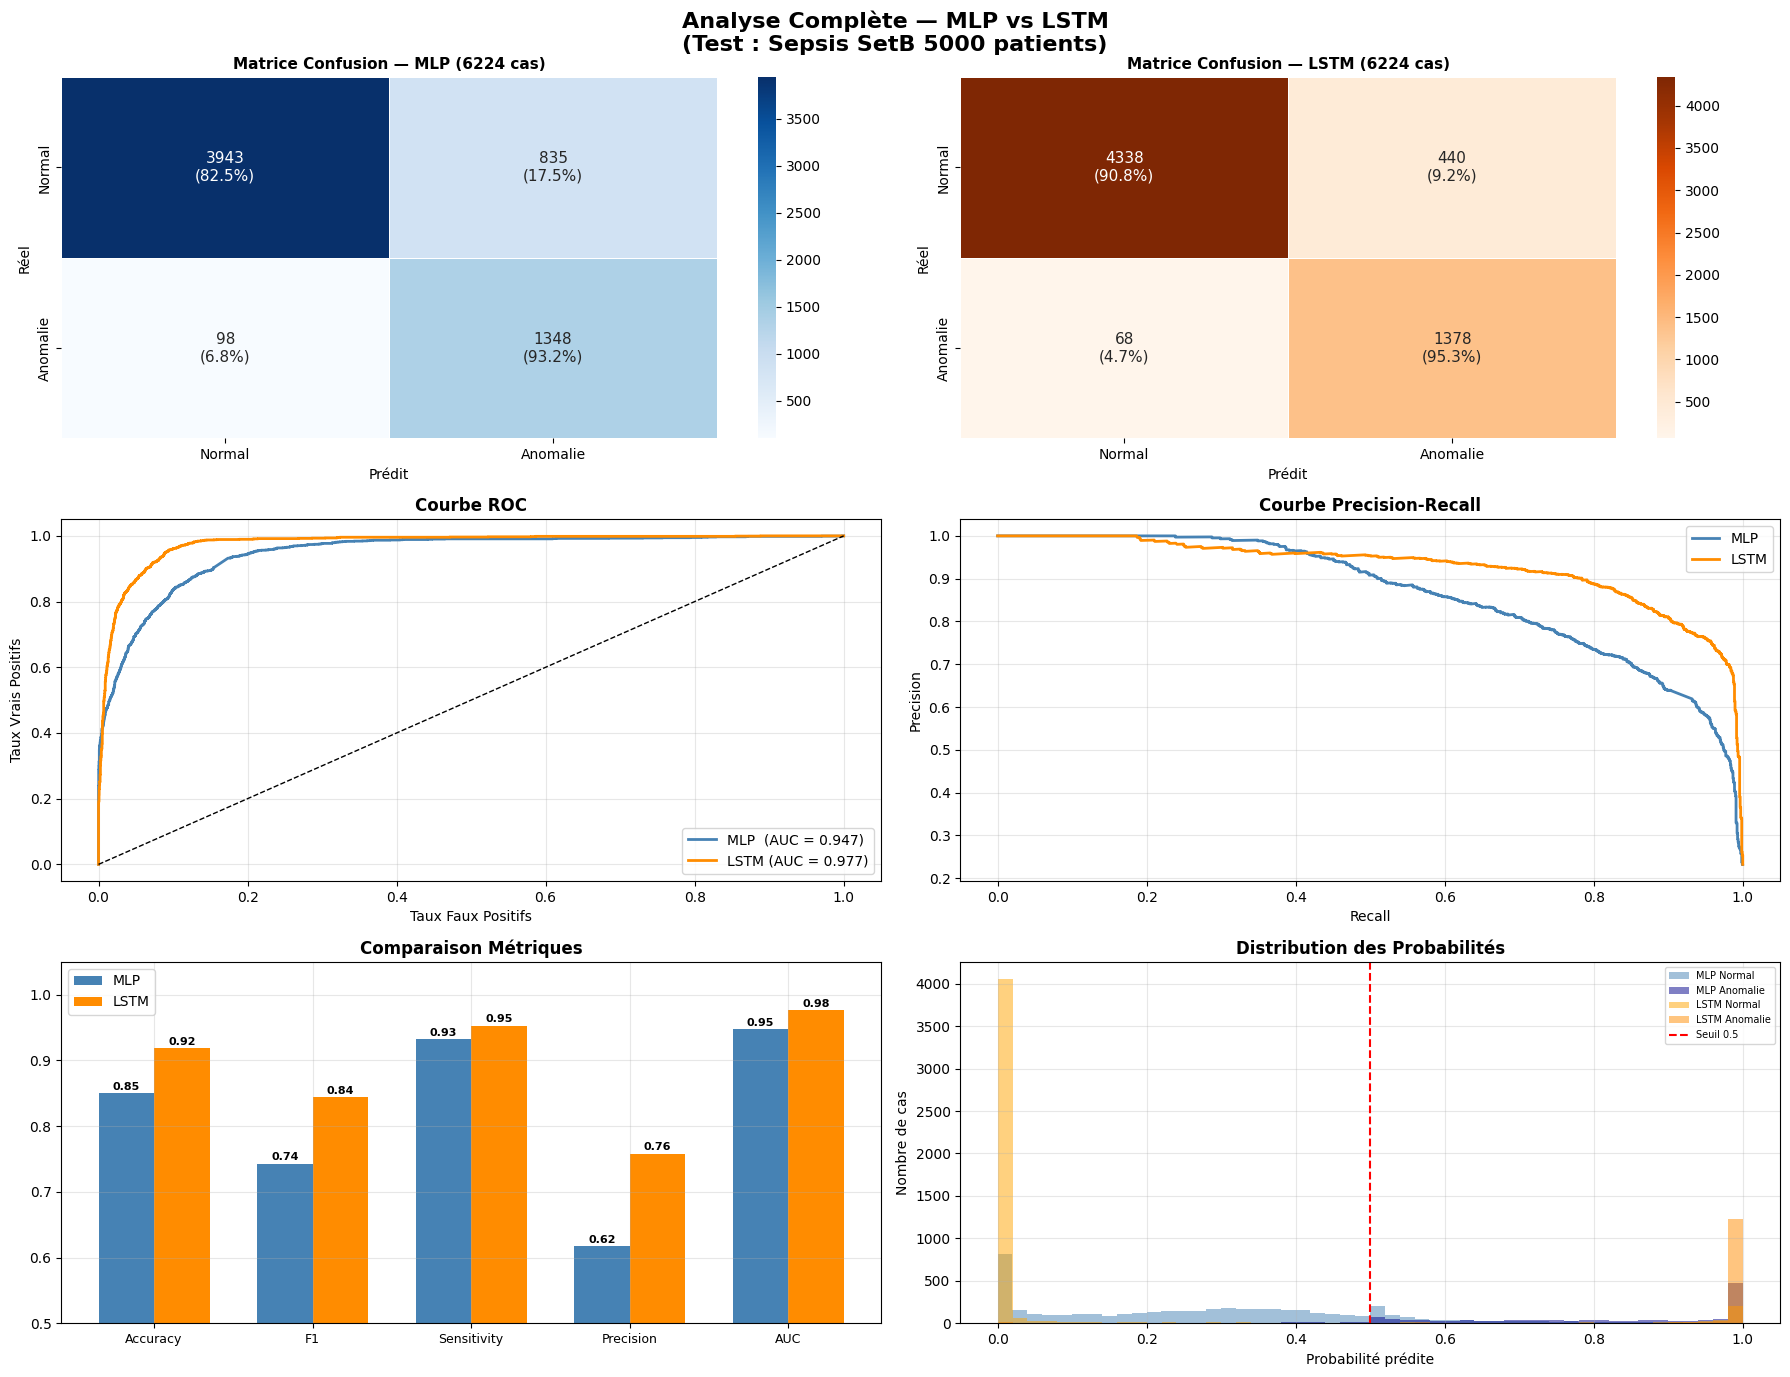

✅ SetB : 6224 cas | Normal : 4778 | Anomalie : 1446

MLP :
              precision    recall  f1-score   support

      Normal       0.98      0.83      0.89      4778
    Anomalie       0.62      0.93      0.74      1446

    accuracy                           0.85      6224
   macro avg       0.80      0.88      0.82      6224
weighted avg       0.89      0.85      0.86      6224

LSTM :
              precision    recall  f1-score   support

      Normal       0.98      0.91      0.94      4778
    Anomalie       0.76      0.95      0.84      1446

    accuracy                           0.92      6224
   macro avg       0.87      0.93      0.89      6224
weighted avg       0.93      0.92      0.92      6224



In [ ]:
# Cellule 13 — Analyse complète SetB
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Analyse Complète — MLP vs LSTM\n(Test : Sepsis SetB 5000 patients)',
             fontsize=16, fontweight='bold')

# 1. Matrice MLP
ax1 = fig.add_subplot(3, 2, 1)
cm_mlp_B = confusion_matrix(y_B, y_pred_mlp_B)
plot_cm(ax1, cm_mlp_B, f'Matrice Confusion — MLP ({len(y_B)} cas)', 'Blues')

# 2. Matrice LSTM
ax2 = fig.add_subplot(3, 2, 2)
cm_lstm_B = confusion_matrix(y_B, y_pred_lstm_B)
plot_cm(ax2, cm_lstm_B, f'Matrice Confusion — LSTM ({len(y_B)} cas)', 'Oranges')

# 3. Courbe ROC
ax3 = fig.add_subplot(3, 2, 3)
fpr_mlp_B, tpr_mlp_B, _ = roc_curve(y_B, y_prob_mlp_B)
fpr_lstm_B, tpr_lstm_B, _ = roc_curve(y_B, y_prob_lstm_B)
auc_mlp_B  = auc(fpr_mlp_B, tpr_mlp_B)
auc_lstm_B = auc(fpr_lstm_B, tpr_lstm_B)
ax3.plot(fpr_mlp_B,  tpr_mlp_B,  color='steelblue',  lw=2, label=f'MLP  (AUC = {auc_mlp_B:.3f})')
ax3.plot(fpr_lstm_B, tpr_lstm_B, color='darkorange', lw=2, label=f'LSTM (AUC = {auc_lstm_B:.3f})')
ax3.plot([0,1], [0,1], 'k--', lw=1)
ax3.set_xlabel('Taux Faux Positifs')
ax3.set_ylabel('Taux Vrais Positifs')
ax3.set_title('Courbe ROC', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Courbe Precision-Recall
ax4 = fig.add_subplot(3, 2, 4)
prec_mlp_B,  rec_mlp_B,  _ = precision_recall_curve(y_B, y_prob_mlp_B)
prec_lstm_B, rec_lstm_B, _ = precision_recall_curve(y_B, y_prob_lstm_B)
ax4.plot(rec_mlp_B,  prec_mlp_B,  color='steelblue',  lw=2, label='MLP')
ax4.plot(rec_lstm_B, prec_lstm_B, color='darkorange', lw=2, label='LSTM')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Courbe Precision-Recall', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Comparaison Métriques
ax5 = fig.add_subplot(3, 2, 5)
metrics = ['Accuracy', 'F1', 'Sensitivity', 'Precision', 'AUC']
mlp_scores  = [accuracy_score(y_B, y_pred_mlp_B),
               f1_score(y_B, y_pred_mlp_B),
               recall_score(y_B, y_pred_mlp_B),
               precision_score(y_B, y_pred_mlp_B),
               auc_mlp_B]
lstm_scores = [accuracy_score(y_B, y_pred_lstm_B),
               f1_score(y_B, y_pred_lstm_B),
               recall_score(y_B, y_pred_lstm_B),
               precision_score(y_B, y_pred_lstm_B),
               auc_lstm_B]
x = np.arange(len(metrics))
width = 0.35
ax5.bar(x - width/2, mlp_scores,  width, label='MLP',  color='steelblue')
ax5.bar(x + width/2, lstm_scores, width, label='LSTM', color='darkorange')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics, fontsize=9)
ax5.set_ylim(0.5, 1.05)
ax5.set_title('Comparaison Métriques', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
for i, (m, l) in enumerate(zip(mlp_scores, lstm_scores)):
    ax5.text(i - width/2, m + 0.005, f'{m:.2f}', ha='center', fontsize=8, fontweight='bold')
    ax5.text(i + width/2, l + 0.005, f'{l:.2f}', ha='center', fontsize=8, fontweight='bold')

# 6. Distribution probabilités
ax6 = fig.add_subplot(3, 2, 6)
ax6.hist(y_prob_mlp_B[y_B==0],  bins=50, alpha=0.5, color='steelblue',  label='MLP Normal')
ax6.hist(y_prob_mlp_B[y_B==1],  bins=50, alpha=0.5, color='darkblue',   label='MLP Anomalie')
ax6.hist(y_prob_lstm_B[y_B==0], bins=50, alpha=0.5, color='orange',     label='LSTM Normal')
ax6.hist(y_prob_lstm_B[y_B==1], bins=50, alpha=0.5, color='darkorange', label='LSTM Anomalie')
ax6.axvline(x=0.5, color='red', linestyle='--', label='Seuil 0.5')
ax6.set_xlabel('Probabilité prédite')
ax6.set_ylabel('Nombre de cas')
ax6.set_title('Distribution des Probabilités', fontweight='bold')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/analyse_SetB.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ SetB : {len(y_B)} cas | Normal : {(y_B==0).sum()} | Anomalie : {(y_B==1).sum()}")
print("\nMLP :")
print(classification_report(y_B, y_pred_mlp_B, target_names=['Normal','Anomalie']))
print("LSTM :")
print(classification_report(y_B, y_pred_lstm_B, target_names=['Normal','Anomalie']))

In [ ]:
# Cellule 14 — Vérification finale tout sur Drive
import os

fichiers = [
    'MLP_VitalDB_final.h5',
    'LSTM_VitalDB_final.h5',
    'scaler_VitalDB_final.pkl',
    'history_mlp_final.json',
    'history_lstm_final.json',
    'df_sepsis_5000.csv',
    'df_sepsis_B_5000.csv',
    'analyse_SetA.png',
    'analyse_SetB.png',
    'courbes_entrainement.png'
]

print("✅ Vérification fichiers sur Drive :")
for f in fichiers:
    path = f'/content/drive/MyDrive/{f}'
    status = "✅" if os.path.exists(path) else "❌"
    print(f"  {status} {f}")

print(f"\n🎉 PFE Edge AI — Terminé !")

✅ Vérification fichiers sur Drive :
  ✅ MLP_VitalDB_final.h5
  ✅ LSTM_VitalDB_final.h5
  ✅ scaler_VitalDB_final.pkl
  ✅ history_mlp_final.json
  ✅ history_lstm_final.json
  ✅ df_sepsis_5000.csv
  ✅ df_sepsis_B_5000.csv
  ✅ analyse_SetA.png
  ✅ analyse_SetB.png
  ✅ courbes_entrainement.png

🎉 PFE Edge AI — Terminé !


In [ ]:
# Rechargement rapide
import tensorflow as tf
import numpy as np
import pandas as pd
import pickle
from google.colab import drive
drive.mount('/content/drive')

# Charger modèle LSTM
model_lstm = tf.keras.models.load_model('/content/drive/MyDrive/LSTM_VitalDB_final.h5')

# Charger scaler
with open('/content/drive/MyDrive/scaler_VitalDB_final.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Charger SetA pour calibration
df_sepsis_A = pd.read_csv('/content/drive/MyDrive/df_sepsis_5000.csv')

print("✅ Tout rechargé !")
print(f"LSTM : {model_lstm.count_params()} paramètres")

Mounted at /content/drive


✅ Tout rechargé !
LSTM : 8017 paramètres


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import pickle
from google.colab import drive
drive.mount('/content/drive')

# Charger modèle LSTM
model_lstm = tf.keras.models.load_model('/content/drive/MyDrive/LSTM_VitalDB_final.h5')

# Charger scaler
with open('/content/drive/MyDrive/scaler_VitalDB_final.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Charger SetA pour calibration
df_sepsis_A = pd.read_csv('/content/drive/MyDrive/df_sepsis_5000.csv')

print("✅ Tout rechargé !")

Mounted at /content/drive


✅ Tout rechargé !


In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
import numpy as np
import pickle
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/scaler_VitalDB_final.pkl', 'rb') as f:
    scaler = pickle.load(f)

import pandas as pd
df_w = pd.read_csv('/content/drive/MyDrive/df_sepsis_A_windows.csv').head(50)
X_calib = scaler.transform(df_w.drop('Target', axis=1).values)
X_calib = X_calib.reshape(X_calib.shape[0], 3, 4).astype(np.float32)

def rep_dataset():
    for i in range(20):
        yield [X_calib[i:i+1]]

model_lstm = tf.keras.models.load_model('/content/drive/MyDrive/LSTM_VitalDB_final.h5')

# Input fixe
inp = tf.keras.layers.Input(batch_shape=(1, 3, 4))
x = tf.keras.layers.LSTM(32, return_sequences=True)(inp)
x = tf.keras.layers.LSTM(16)(x)
x = tf.keras.layers.Dense(8, activation='relu')(x)
out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model_fixed = tf.keras.Model(inp, out)
model_fixed.set_weights(model_lstm.get_weights())

del model_lstm
import gc
gc.collect()

# Conversion avec SELECT_TF_OPS
converter = tf.lite.TFLiteConverter.from_keras_model(model_fixed)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('/content/drive/MyDrive/lstm_select_ops.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ LSTM TFLite : {len(tflite_model)/1024:.1f} KB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saved artifact at '/tmp/tmpg_9sqbnp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 3, 4), dtype=tf.float32, name='keras_tensor_25')
Output Type:
  TensorSpec(shape=(1, 1), dtype=tf.float32, name=None)
Captures:
  138639970201104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937227664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937231888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937228624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937225936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937232656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937232848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937227088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937227280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138639937230544: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ LSTM TFLite : 36.3 KB


In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import tensorflow as tf
import pickle
from google.colab import drive
drive.mount('/content/drive')

model_mlp = tf.keras.models.load_model('/content/drive/MyDrive/MLP_VitalDB_final.h5')

# Conversion MLP → TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_mlp)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Générer mlp_model.h
h_content = '#pragma once\n\n'
h_content += f'const unsigned int mlp_model_len = {len(tflite_model)};\n\n'
h_content += 'alignas(8) const unsigned char mlp_model_data[] = {\n  '
hex_values = [f'0x{b:02x}' for b in tflite_model]
for i, val in enumerate(hex_values):
    h_content += val
    if i < len(hex_values) - 1:
        h_content += ', '
    if (i + 1) % 12 == 0:
        h_content += '\n  '
h_content += '\n};\n'

with open('/content/drive/MyDrive/mlp_model.h', 'w') as f:
    f.write(h_content)

print(f"✅ MLP TFLite : {len(tflite_model)/1024:.1f} KB")
print(f"✅ mlp_model.h sauvegardé !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saved artifact at '/tmp/tmpjgt5elc6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137229642406928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642407696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642406352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642407120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642408272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642408848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642410192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137229642410576: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ MLP TFLite : 10.3 KB
✅ mlp_model.h sauvegardé !
